In [1]:
import numpy as np
import sys
sys.path.append("../")
sys.path.append("../Visualization/")
sys.path.append("../../")

In [2]:
sys.path.append("../../experiments/parametrization_experiments/")

In [3]:
sys.path.append('../../'); sys.path.append('../../../'); sys.path.append('../../../gmsh'); sys.path.append('../../Visualization/')
import inflation, sparse_matrices, mesh, numpy as np, importlib, pickle
import inflatables_parametrization as parametrization
from numpy.linalg import norm
from io_redirection import suppress_stdout
import visualization

In [4]:
import visualize_stiffness, importlib
importlib.reload(visualize_stiffness)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

In [5]:
sys.path.append('periodic_patches/')
sys.path.append('gmsh')

In [6]:
import parametrization_helper

In [7]:
import parametrization_experiment_helper, importlib
importlib.reload(parametrization_experiment_helper)

<module 'parametrization_experiment_helper' from '/Users/yren/Develop/Inflatables/python/periodic_patches/pipeline/inverse_design/../../experiments/parametrization_experiments/parametrization_experiment_helper.py'>

In [8]:
pattern = parametrization_experiment_helper.Pattern_data[1]

In [9]:
experiment_file = pattern['experiment_file']
stiffness_path = pattern['stiffness_path']
pattern_name = pattern['name']
num_pattern_params = pattern['num_pattern_params']
param_index = pattern['param_index']
default_param = pattern['default_param']
param_range = pattern['param_range']
param_normalization_factor = pattern['param_normalization_factor']
fusing_curve_polyline = pattern['fusing_curve_polyline_function']
                                

In [10]:
shape = parametrization_experiment_helper.Shape_data[3]

In [11]:
shape_name = shape['name']
shape_path = shape['path']

In [12]:
import utils, mesh_utilities, benchmark

In [13]:
data_path = '../../experiments/parametrization_experiments/igloo_cosine_curve_amplitude_full_period/2024_01_15_17_18/'

In [14]:
target_surf = mesh.Mesh(shape_path)
target_surf.setVertices(utils.prototypeScaleNormalization(target_surf.vertices(), placeAtopFloor=False))
target_surf = mesh_utilities.subdivide_loop(target_surf, 1)

In [15]:
target_surf.save(data_path + 'target_surf.obj')

## Upsampling and channel generation

In [16]:
sdfVertices, sdfTris, sdf, sheet_vxs, concatenated_polylines, sheet_edges_polylines,  boundaryVxs, boundaryEdges, upsampleMesh_vertices, upsampleMesh_triangles, upsampledAngles, upsampledPatternParams = parametrization_helper.get_polyline_from_pattern_parameters(_, fusing_curve_polyline, nsubdiv = 4, frequency=0.2, duplicates_removable_threshold=[1e-4, 1e-2, 1e-1, 1e0, 2e0], path = data_path, load_data = 'final_results')

In [17]:
import pickle, mesh, wall_generation, visualization, numpy as np

In [18]:
if len(boundaryEdges) > 1:
    concatenated_boundary_edges = []
    for polyline in boundaryEdges:
        concatenated_boundary_edges.extend(polyline)
    concatenated_boundary_edges = np.array(concatenated_boundary_edges)
    # Define a function to calculate the length of a sublist
    def sublist_length(sublist):
        return len(sublist)

    # Sort boundaryEdges in descending order of sublist length
    boundaryEdges = sorted(boundaryEdges, key=sublist_length, reverse=True)
else:
    concatenated_boundary_edges = np.array(boundaryEdges[0])


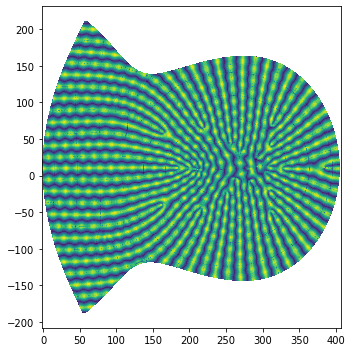

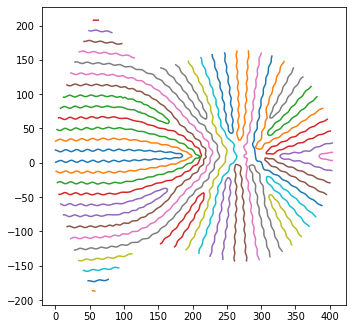

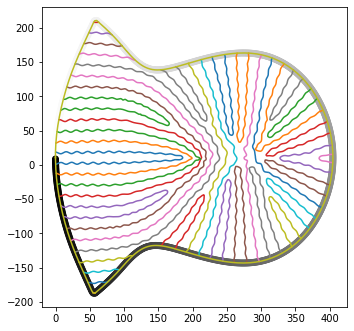

In [19]:
visualization.scalarFieldPlotFast(sdfVertices, sdfTris, sdf, width = 5, height=5)
visualization.plot_line_segments(sheet_vxs, concatenated_polylines, width = 5, height = 5)
visualization.plot_line_segments(list(sheet_vxs) + list(boundaryVxs), list(concatenated_polylines) + list(concatenated_boundary_edges + len(sheet_vxs)), width = 5, height = 5)
plt.scatter(boundaryVxs[concatenated_boundary_edges[:,0], 0], boundaryVxs[concatenated_boundary_edges[:,0], 1], c = np.arange(len(concatenated_boundary_edges[:, 0])), cmap = mpl.colormaps['Greys'])

## Meshing and inflation simulation

In [20]:
import mesher_helper
importlib.reload(mesher_helper)

<module 'mesher_helper' from '/Users/yren/Develop/Inflatables/python/periodic_patches/pipeline/inverse_design/../../../gmsh/mesher_helper.py'>

In [21]:
default_frequency = 0.2
default_mesh_size = 4
default_edge_soup_threshold = 1e0

scale = 1

frequency = default_frequency * scale
# mesh_size = default_mesh_size / scale
edge_soup_threshold = default_edge_soup_threshold

In [22]:
selected_elements = [np.array(sublist)[:, 0] for sublist in boundaryEdges[1:]]
holes_vxs = boundaryVxs[selected_elements]

In [23]:
importlib.reload(mesher_helper)

<module 'mesher_helper' from '/Users/yren/Develop/Inflatables/python/periodic_patches/pipeline/inverse_design/../../../gmsh/mesher_helper.py'>

In [24]:
v, f, fusing_data = mesher_helper.generate_mesh_non_periodic(default_mesh_size, boundaryVxs[np.array(boundaryEdges[0])[:, 0]], holes_vxs, sheet_vxs, concatenated_polylines, gui = False)

TypeError: generate_mesh_non_periodic() missing 1 required positional argument: 'embeddings_lines'

In [25]:
import MeshFEM

In [26]:
import numpy as np
import copy

# Use the function
new_v, new_f, new_fusing_without_boundary = parametrization_helper.remove_dangling_vertices(v, f - 1, fusing_data)
m = MeshFEM.mesh.Mesh(new_v, new_f)
new_fusing = copy.copy(new_fusing_without_boundary)
new_fusing[m.boundaryVertices()] = True

NameError: name 'v' is not defined

In [24]:
fusing_data, new_fusing

In [25]:
# m, iwv, iwbv = sheet_meshing.newMeshingAlgorithm(sdfVertices, sdfTris, sdf, SV, SE, triArea=1e0)


In [26]:
visualization.plot_2d_mesh(m, pointList=np.where(np.array(new_fusing) == 1)[0], width=10, height=10)


### Save pattern

In [27]:
import inflation
isheet = inflation.InflatableSheet(m, new_fusing)

In [28]:
import shapely
channelMargin = 11

In [35]:
import time

In [36]:
time_stamp = time.strftime("%Y_%m_%d_%H_%M")

In [120]:
importlib.reload(parametrization_helper)

In [38]:
if not 'rparam' in globals():
    uv = np.load(data_path + '/rparam_uv.npy')
else:
    uv = rparam.uv()

In [45]:
from mesh_utilities import SurfaceSampler, tubeRemesh


paramSampler = SurfaceSampler(np.pad(uv, [(0, 0), (0, 1)], 'constant'), target_surf.triangles())
liftedSheetPositions = paramSampler.sample(m.vertices(), target_surf.vertices())

isheet.setUninflatedDeformation(liftedSheetPositions.transpose())

isheet.getVars()

In [46]:
import py_newton_optimizer
niter = 2000
iterations_per_output = 10
opts = py_newton_optimizer.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.gradTol = 1e-10
opts.niter = iterations_per_output

In [170]:
sys.path.append("../../")


In [172]:
importlib.reload(visualization)

In [173]:
from visualization import TriMeshViewerWithSurface

In [174]:

viewer = TriMeshViewerWithSurface(isheet, target_surf, width=768, height=640)
viewer.showWireframe(True)

viewer.show()

In [160]:
# Are the flat region causing a problem? They might not actually control the metric...
# Try replacing them with single wall...
# Analyze the actual stretching factor (much easier to do with skeleton walls)

from tri_mesh_viewer import TriMeshViewer
viewer = TriMeshViewer(isheet, width=768, height=640)
viewer.showWireframe(True)

viewer.show()

In [169]:
viewer.setCameraParams(((1.613494603240345, -3.9332708615926393, 1.4922998234349831),
 (-0.05948468564942635, 0.33267929672385665, 0.941162078339598),
 (0.0, 0.0, 0.0)))

In [162]:
viewer.getCameraParams()

In [48]:
viewer.update(scalarField=utils.getStrains(isheet)[:, 0])    

In [49]:
import boundaries
bdryVars = boundaries.getOuterBoundaryVars(isheet)
fixedVars = bdryVars

In [50]:
isheet.setUseTensionFieldEnergy(True)

isheet.setUseHessianProjectedEnergy(False)

fixedVars, hessianShift = [], 1e-6

framerate = 20
def cb(it):
    if it % framerate == 0:
        viewer.update(scalarField=utils.getStrains(isheet)[:, 0])    

### First solve with low pressure to get out of indefinite state

In [51]:
isheet.pressure = 1e-5

In [52]:
opts.niter = 5

import time
cr = inflation.inflation_newton(isheet, fixedVars, opts, hessianShift = hessianShift, callback = cb)

### Then inflate

In [53]:
isheet.pressure = 0.025

In [56]:
opts.niter = 2000
opts.gradTol = 1e-7

import time
benchmark.reset()
cr = inflation.inflation_newton(isheet, fixedVars, opts, hessianShift = hessianShift, callback = cb)
benchmark.report()

isheet.tensionStateHistogram()

In [58]:
def export_top_bottom_mesh(isheet, export_path, shape_name, pattern_name):
    mesh_3d = isheet.visualizationMesh(True)
    mesh_2d = isheet.mesh()
    vx_3d = mesh_3d.vertices()
    elements_3d = mesh_3d.elements()

    new_mesh_3d = MeshFEM.Mesh(vx_3d[:mesh_2d.numVertices()], elements_3d[:mesh_2d.numElements()])

    new_mesh_3d.save(export_path + '{}_{}_mesh_3d_top.obj'.format(shape_name, pattern_name))

    new_mesh_3d = MeshFEM.Mesh(vx_3d[m.numVertices():], elements_3d[mesh_2d.numElements():] - mesh_2d.numVertices())
    new_mesh_3d.save(export_path + '{}_{}_mesh_3d_bottom.obj'.format(shape_name, pattern_name))

In [59]:
export_top_bottom_mesh(isheet, data_path, shape_name, pattern_name)

In [ ]:
# isheet.nu
# for i in range(len(isheet.mesh().vertices())):
#     if (isheet.varIdx(0, i) !=  isheet.varIdx(1, i)):
#         print(isheet.varIdx(0, i), isheet.varIdx(1, i))

In [113]:
# Plot maximum tensile strains in the sheet to verify the pressure is reasonable
from matplotlib import pyplot as plt
plt.hist(utils.getStrains(isheet)[:, 0], bins=1000);
plt.xlim(-0.04, 0.1);

## Shape Optimization

In [60]:
# Reset the inflation and set up target-attraction forces
isheet.setUninflatedDeformation(liftedSheetPositions.transpose(), prepareRigidMotionPinConstraints=False)
targetAttractedSheet = inflation.TargetAttractedInflation(isheet, target_surf)
targetAttractedSheet.energy(targetAttractedSheet.EnergyType.Fitting)

In [70]:
targetAttractedSheet.targetSurfaceFitter().holdClosestPointsFixed = True
targetAttractedSheet.fittingWeight = 1e-5

In [62]:
# Re-inflate, this time applying target-attraction forces.
import time
isheet.pressure = 0.025


benchmark.reset()
cr = inflation.inflation_newton(targetAttractedSheet, fixedVars, opts, hessianShift = hessianShift, callback = cb)
benchmark.report()

In [63]:
# Set up the sheet optimizer
import sheet_optimizer, opt_config
origDesignMesh = isheet.mesh().copy()

sheet_opt = sheet_optimizer.PySheetOptimizer(targetAttractedSheet, fixedVars, renderMode=sheet_optimizer.RenderMode.PYTHREEJS,
                                             detActivationThreshold=0.9, detActivationThresholdTubeTri=0.5,
                                             originalDesignMesh=origDesignMesh, fusingCurveSmoothnessConfig=opt_config.FusingCurveSmoothnessParams(0.0, 0.0, 1.0, 1.0))

In [64]:
# Configure some more weights
sheet_opt.rso.compressionPenaltyWeight = 1e-6
fcs = sheet_opt.rso.fusingCurveSmoothness()
fcs.interiorWeight = 0.05

In [65]:
sheet_opt.flat_viewer.showWireframe()
sheet_opt.viewer()

In [66]:
# Run the optimization
sheet_opt.setSolver(sheet_optimizer.Solver.SCIPY)
sheet_opt.optimize()

In [67]:
time_stamp = time.strftime("%Y_%m_%d_%H_%M")

In [68]:
sheet_opt.save('{}_igloo_optimized_sheet_opt.pkl.gz'.format(time_stamp))

In [ ]:
# Lower the interior weight
fcs = sheet_opt.rso.fusingCurveSmoothness()
fcs.interiorWeight = 0.05

In [ ]:
# Continue the optimization
sheet_opt.optimize()

In [ ]:
utils.allGradientNorms(sheet_opt.rso)

In [ ]:
utils.allEnergies(sheet_opt.rso)

In [69]:
# Remove the target-attraction force and recompute the equilibrium
targetAttractedSheet.fittingWeight = 1e-8
inflation.inflation_newton(targetAttractedSheet, sheet_opt.rso.fixedEquilibriumVars(), sheet_opt.opts)
viewer.update()

In [ ]:
# Save the full state for later reloading with `sheet_optimizer.load()`
sheet_opt.save('sheet_opt.pkl.gz')

### Generate Fabrication Files

In [71]:
scaleFactor = 1 # Factor for fine-tuning size to fit the machine's build area
channelMargin = 6 / scaleFactor # 8mm channel margin
tabMargin = 0

In [72]:
isheet = sheet_opt.rso.sheet()
optMesh = sheet_opt.rso.mesh().copy()
origMesh = sheet_opt.rso.originalMesh().copy()
import inflation
tas = sheet_opt.rso.targetAttractedInflation()
tsf = tas.targetSurfaceFitter()
targetSurf = mesh.Mesh(tsf.targetSurfaceV, tsf.targetSurfaceF)
iwv = [isheet.isWallVtx(i) for i in range(isheet.mesh().numVertices())]

In [74]:
import fabrication
importlib.reload(fabrication)
fabrication.writeFabricationData('fabrication_data/igloo/{}'.format(pattern_name), origMesh, optMesh, iwv, targetSurf, uv,
                                 scale=scaleFactor, numTabs=0, inletOffset=0, tabOffset=0,
                                 channelMargin=channelMargin, tabMargin=tabMargin, tabWidth=5, tabHeight=8, fuseSeamWidth=0.01, inletScale=0,
                                 overlap=0.0, smartOuterChannel=True)

In [87]:
fused_edge_soup = []
def get_fused_edge_soup(edge, i):
    v1, v2 = edge
    if (fusing_data[v1] and fusing_data[v2]):
        fused_edge_soup.append([v1, v2])

In [88]:
m.visitEdges(get_fused_edge_soup)

In [165]:
final_vertices, concatenated_polylines = parametrization_helper.get_fabrication_file_from_mesh(isheet, origMesh, new_fusing, channelMargin, [1e-4, 1e-4, 1e-4],'{}_{}_sheet_pattern_{}_margin_{}.obj'.format(shape_name, pattern_name, time_stamp, channelMargin))

In [166]:
visualization.plot_line_segments(final_vertices, concatenated_polylines, width = 10, height = 10)

In [167]:
final_vertices, concatenated_polylines = parametrization_helper.get_fabrication_file_from_mesh(isheet, isheet.mesh(), new_fusing, channelMargin, [1e-4, 1e-4, 1e-4],'{}_{}_design_optimized_sheet_pattern_{}_margin_{}.obj'.format(shape_name, pattern_name, time_stamp, channelMargin))

In [168]:
visualization.plot_line_segments(final_vertices, concatenated_polylines, width = 10, height = 10)

In [146]:
import inflation
ori_isheet = inflation.InflatableSheet(origMesh, new_fusing)

In [147]:
if not 'rparam' in globals():
    uv = np.load(data_path + '/rparam_uv.npy')
else:
    uv = rparam.uv()

In [148]:
from mesh_utilities import SurfaceSampler, tubeRemesh


paramSampler = SurfaceSampler(np.pad(uv, [(0, 0), (0, 1)], 'constant'), target_surf.triangles())
liftedSheetPositions = paramSampler.sample(m.vertices(), target_surf.vertices())

ori_isheet.setUninflatedDeformation(liftedSheetPositions.transpose())

In [149]:
import py_newton_optimizer
niter = 2000
iterations_per_output = 10
opts = py_newton_optimizer.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.gradTol = 1e-10
opts.niter = iterations_per_output

In [175]:
from visualization import TriMeshViewerWithSurface
ori_viewer = TriMeshViewerWithSurface(ori_isheet, target_surf, width=768, height=640)
ori_viewer.showWireframe(True)

ori_viewer.show()

In [151]:
ori_viewer.update(scalarField=utils.getStrains(ori_isheet)[:, 0])    

In [152]:
import boundaries
bdryVars = boundaries.getOuterBoundaryVars(ori_isheet)
fixedVars = bdryVars

In [153]:
ori_isheet.setUseTensionFieldEnergy(True)

ori_isheet.setUseHessianProjectedEnergy(False)

fixedVars, hessianShift = [], 1e-6

framerate = 20
def cb(it):
    if it % framerate == 0:
        ori_viewer.update(scalarField=utils.getStrains(ori_isheet)[:, 0])    

### First solve with low pressure to get out of indefinite state

In [154]:
ori_isheet.pressure = 1e-5

In [155]:
opts.niter = 5

import time
cr = inflation.inflation_newton(ori_isheet, fixedVars, opts, hessianShift = hessianShift, callback = cb)

### Then inflate

In [156]:
ori_isheet.pressure = 0.025

In [157]:
opts.niter = 2000
opts.gradTol = 1e-7

import time
benchmark.reset()
cr = inflation.inflation_newton(ori_isheet, fixedVars, opts, hessianShift = hessianShift, callback = cb)
benchmark.report()

ori_isheet.tensionStateHistogram()

In [146]:
import inflation
opt_isheet = inflation.InflatableSheet(opt, new_fusing)

In [147]:
if not 'rparam' in globals():
    uv = np.load(data_path + '/rparam_uv.npy')
else:
    uv = rparam.uv()

In [148]:
from mesh_utilities import SurfaceSampler, tubeRemesh


paramSampler = SurfaceSampler(np.pad(uv, [(0, 0), (0, 1)], 'constant'), target_surf.triangles())
liftedSheetPositions = paramSampler.sample(m.vertices(), target_surf.vertices())

ori_isheet.setUninflatedDeformation(liftedSheetPositions.transpose())

In [149]:
import py_newton_optimizer
niter = 2000
iterations_per_output = 10
opts = py_newton_optimizer.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.gradTol = 1e-10
opts.niter = iterations_per_output

In [150]:
# Are the flat region causing a problem? They might not actually control the metric...
# Try replacing them with single wall...
# Analyze the actual stretching factor (much easier to do with skeleton walls)

from tri_mesh_viewer import TriMeshViewer
ori_viewer = TriMeshViewer(ori_isheet, width=768, height=640)
ori_viewer.showWireframe(True)

ori_viewer.show()

In [163]:
ori_viewer.setCameraParams(((-4.216072304659389, -2.2442061236289987, 0.8425385486414142),
 (0.10069732311666361, 0.1782983614843271, 0.9788103715271664),
 (0.0, 0.0, 0.0)))

In [159]:
ori_viewer.getCameraParams()

In [151]:
ori_viewer.update(scalarField=utils.getStrains(ori_isheet)[:, 0])    

In [152]:
import boundaries
bdryVars = boundaries.getOuterBoundaryVars(ori_isheet)
fixedVars = bdryVars

In [153]:
ori_isheet.setUseTensionFieldEnergy(True)

ori_isheet.setUseHessianProjectedEnergy(False)

fixedVars, hessianShift = [], 1e-6

framerate = 20
def cb(it):
    if it % framerate == 0:
        ori_viewer.update(scalarField=utils.getStrains(ori_isheet)[:, 0])    

### First solve with low pressure to get out of indefinite state

In [154]:
ori_isheet.pressure = 1e-5

In [155]:
opts.niter = 5

import time
cr = inflation.inflation_newton(ori_isheet, fixedVars, opts, hessianShift = hessianShift, callback = cb)

### Then inflate

In [156]:
ori_isheet.pressure = 0.025

In [ ]:
opts.niter = 2000
opts.gradTol = 1e-7

import time
benchmark.reset()
cr = inflation.inflation_newton(ori_isheet, fixedVars, opts, hessianShift = hessianShift, callback = cb)
benchmark.report()

ori_isheet.tensionStateHistogram()